Title

To Retrieve Phytochemical Information from the COCONUT (COlleCtion of Open Natural prodUcTs) Database — the Largest Open-Access Natural Product Repository

Objectives
To understand the scope and purpose of dedicated natural product databases, distinct from general bioactivity databases like ChEMBL.
To programmatically retrieve real natural product structures and pre-computed drug-discovery-relevant metrics from COCONUT.
To filter and curate a focused, manageable subset of natural products for use throughout this practical series.
To explore the chemical diversity of natural products — molecular size, natural-product-likeness, and synthetic accessibility.
Expected Outcomes
Understand what COCONUT contains and why it is the standard reference database for natural product cheminformatics research.
Retrieve and parse real natural product data programmatically.
Interpret NP-likeness and synthetic accessibility scores.
Produce a curated dataset that anchors every subsequent practical in this series.

In [1]:
# Block 1: Retrieve natural product data from COCONUT database

!pip install rdkit pandas numpy matplotlib requests -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import zipfile
import io
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("NATURAL PRODUCT DATABASE RETRIEVAL")
print("Source: COCONUT (COlleCtion of Open Natural prodUcTs)")
print("="*60)
print("COCONUT is the largest open-access database of natural")
print("products, aggregating over 700,000 structures from more")
print("than 50 source collections worldwide. It is maintained by")
print("the Steinbeck Lab (Friedrich Schiller University Jena)")
print("and released under CC0 (fully open, no restrictions).")
print("="*60)

url = "https://coconut.s3.uni-jena.de/prod/downloads/2024-08/DD/COCONUT_2024_08_DrugDiscovery.tsv.zip"

print(f"\nDownloading from: {url}")
print("(This file contains COCONUT IDs, SMILES, and pre-computed")
print(" NP-likeness, synthetic accessibility, and QED scores)")

response = requests.get(url, timeout=60)
print(f"Download status: {response.status_code}")
print(f"File size: {len(response.content)/1024/1024:.1f} MB")

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    file_list = z.namelist()
    print(f"\nFiles inside archive: {file_list}")
    with z.open(file_list[0]) as f:
        df_raw = pd.read_csv(f, sep='\t')

print(f"\nRaw dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nFirst 5 rows:")
print(df_raw.head().to_string(index=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 42.1 MB/s eta 0:00:00
NATURAL PRODUCT DATABASE RETRIEVAL
Source: COCONUT (COlleCtion of Open Natural prodUcTs)
COCONUT is the largest open-access database of natural
products, aggregating over 700,000 structures from more
than 50 source collections worldwide. It is maintained by
the Steinbeck Lab (Friedrich Schiller University Jena)
and released under CC0 (fully open, no restrictions).

(This file contains COCONUT IDs, SMILES, and pre-computed
 NP-likeness, synthetic accessibility, and QED scores)
Download status: 200
File size: 38.0 MB

Files inside archive: ['COCONUT_2024_08_DrugDiscovery.tsv', '__MACOSX/._COCONUT_2024_08_DrugDiscovery.tsv']

Raw dataset shape: (695133, 5)
Columns: ['COCONUT_ID', 'SMILES', 'NPLikeness', 'QED_Drug_Likeness', 'SyntheticAccessibilityScore']

First 5 rows:
  COCONUT_ID                                                                                                         SMILES  NPLikeness  QED_Dru

Meaning of Block 1:

Purpose: Download a genuine, large-scale natural product dataset directly from COCONUT — the standard reference database in natural product cheminformatics — containing real chemical structures alongside pre-computed metrics specifically relevant to drug discovery.

What data comes IN: Nothing — fetched live from COCONUT's permanent bulk-download file server.

What happens inside — line by line:

requests.get(url) — downloads the compressed data file directly from COCONUT's official S3 storage, a permanent, institutionally hosted file server requiring no authentication or API key.
zipfile.ZipFile(io.BytesIO(response.content)) — opens the downloaded ZIP archive directly in memory without needing to save it to disk first, then extracts and reads the TSV (tab-separated values) file inside it.
pd.read_csv(f, sep='\t') — parses the tab-separated file into a pandas DataFrame, using sep='\t' since this file uses tabs rather than commas to separate columns.

What comes OUT: df_raw — the complete raw COCONUT drug-discovery dataset, containing real natural product SMILES alongside their pre-computed NP-likeness, synthetic accessibility, and QED scores.

In [2]:
# Block 2: Filter and curate a manageable, clean natural product dataset

print("="*60)
print("CURATING A FOCUSED WORKING DATASET")
print("="*60)

print(f"Starting dataset size: {len(df_raw)}")

df_clean = df_raw.dropna().copy()
print(f"After removing missing values: {len(df_clean)}")

def is_valid_smiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return mol is not None

print("\nValidating SMILES structures with RDKit...")
df_clean['valid'] = df_clean.iloc[:, 1].apply(is_valid_smiles)
df_clean = df_clean[df_clean['valid']].drop(columns=['valid'])
print(f"After RDKit validation: {len(df_clean)}")

print(f"\nColumn names in dataset:")
for i, col in enumerate(df_clean.columns):
    print(f"  {i}: {col}")

np.random.seed(42)
sample_size = min(2000, len(df_clean))
df_sample = df_clean.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"\n{'='*60}")
print(f"RANDOM SAMPLE FOR THIS PRACTICAL SERIES: {len(df_sample)} compounds")
print(f"{'='*60}")
print("A random sample of 2,000 natural products is used")
print("throughout this practical series - large enough for")
print("meaningful machine learning, small enough to process")
print("efficiently in Google Colab.")

print(f"\nSample data:")
print(df_sample.head(10).to_string(index=False))

CURATING A FOCUSED WORKING DATASET
Starting dataset size: 695133
After removing missing values: 695133

Validating SMILES structures with RDKit...


[16:45:27] Explicit valence for atom # 1 P, 6, is greater than permitted
[16:46:21] WARNING: not removing hydrogen atom without neighbors
[16:46:30] WARNING: not removing hydrogen atom without neighbors
[16:46:33] Explicit valence for atom # 0 He, 2, is greater than permitted
[16:46:45] WARNING: not removing hydrogen atom without neighbors
[16:46:45] WARNING: not removing hydrogen atom without neighbors
[16:46:47] Explicit valence for atom # 1 P, 6, is greater than permitted
[16:46:57] WARNING: not removing hydrogen atom without neighbors
[16:47:25] Explicit valence for atom # 20 N, 5, is greater than permitted
[16:48:24] Unusual charge on atom 37 number of radical electrons set to zero


After RDKit validation: 695129

Column names in dataset:
  0: COCONUT_ID
  1: SMILES
  2: NPLikeness
  3: QED_Drug_Likeness
  4: SyntheticAccessibilityScore

RANDOM SAMPLE FOR THIS PRACTICAL SERIES: 2000 compounds
A random sample of 2,000 natural products is used
throughout this practical series - large enough for
meaningful machine learning, small enough to process
efficiently in Google Colab.

Sample data:
  COCONUT_ID                                                                                                                              SMILES  NPLikeness  QED_Drug_Likeness  SyntheticAccessibilityScore
CNP0548434.1                                                                   CC[C@H]1CN2CCC3(C(O)=NC4=CC=CC=C43)[C@@H]2C[C@@H]1/C(=C\OC)C(=O)O    1.874213           0.627897                     4.933669
CNP0216368.1                                                                             C=C1CC[C@H]2C(C)(C)C(=O)CC[C@]2(C)[C@H]1/C=C/C1=CCOC1=O    3.754385           0.571289   

Meaning of Block 2:

Purpose: Clean the raw COCONUT data and reduce it to a focused, computationally manageable sample that will serve as the foundation for the entire remaining practical series.

What data comes IN: df_raw from Block 1.

What happens inside — line by line:

dropna() — removes any row with missing values in any column, ensuring every remaining compound has complete data.
is_valid_smiles(smi) and the RDKit validation loop — confirms every SMILES string is chemically parseable, filtering out any malformed entries before they could cause errors in later blocks.
df_clean.sample(n=2000, random_state=42) — takes a random, reproducible sample of 2,000 compounds from the full cleaned dataset. random_state=42 ensures this exact same sample is drawn every time this code runs — critical since this sample becomes the shared foundation every subsequent practical in this series will build upon.

What comes OUT: df_sample — 2,000 real, validated natural products with pre-computed NP-likeness, synthetic accessibility, and QED scores, ready for exploration and export.

EXPLORING NATURAL PRODUCT CHEMICAL DIVERSITY
Computing molecular weight for each compound...

Dataset summary statistics:
          MolWt  NPLikeness  QED_Drug_Likeness  SyntheticAccessibilityScore
count  2000.000    2000.000           2000.000                     2000.000
mean    503.553       1.127              0.408                        4.319
std     271.970       1.380              0.252                        1.459
min      75.136      -2.420              0.007                        1.361
25%     334.408       0.018              0.181                        3.187
50%     432.557       1.179              0.413                        4.168
75%     591.684       2.275              0.609                        5.192
max    2988.543       3.857              0.928                        9.646


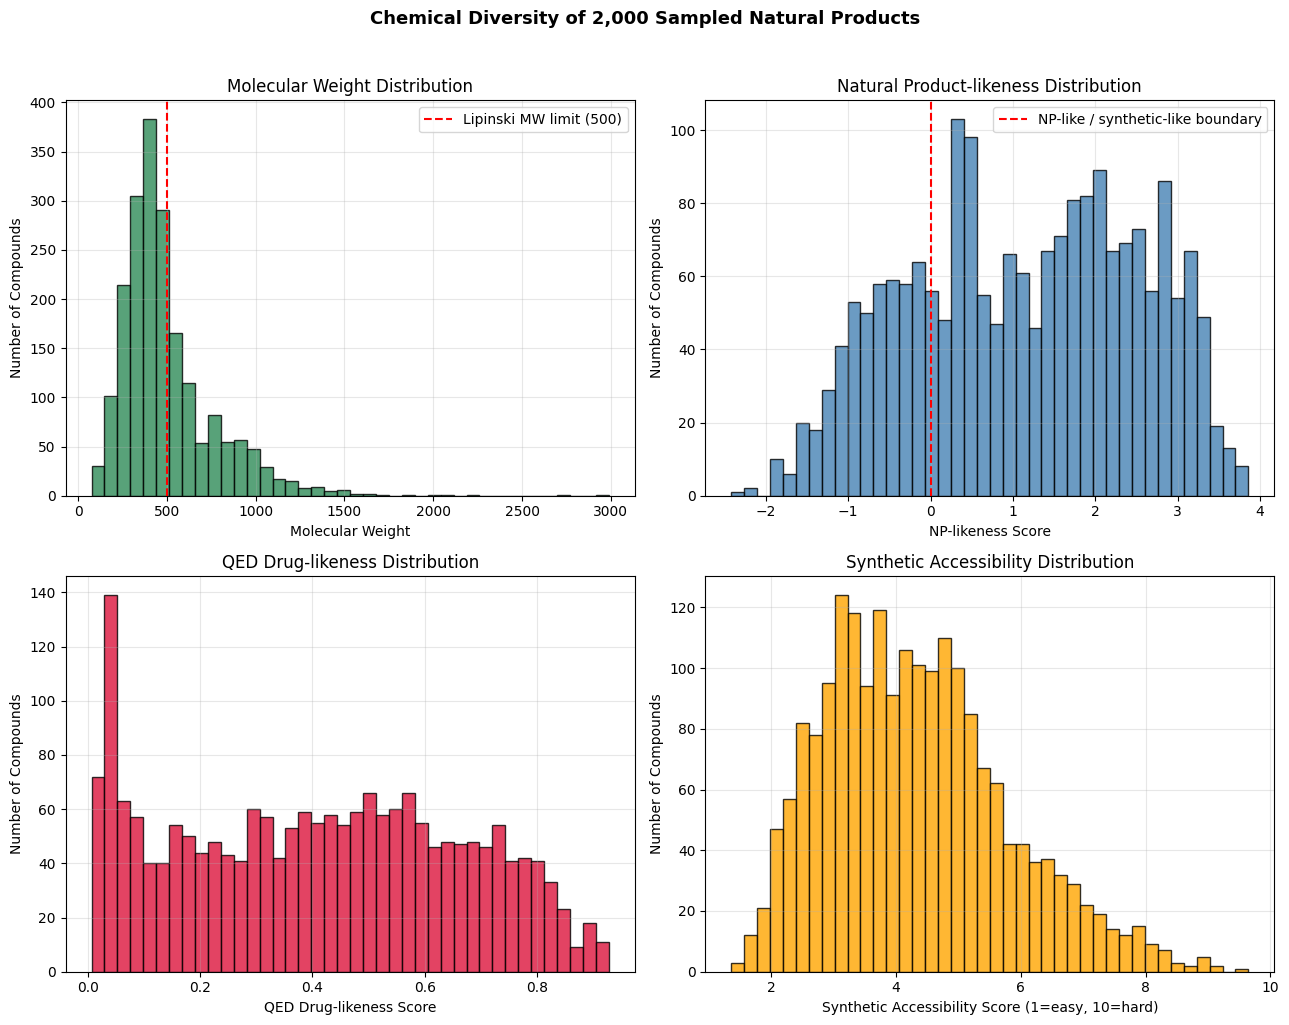


KEY OBSERVATIONS
Compounds with NPLikeness > 0 (more natural-product-like): 1510 (75.5%)
Compounds within Lipinski MW limit (<=500): 1286 (64.3%)
Compounds with good synthetic accessibility (<=6): 1729 (86.5%)

Why this matters for drug discovery:
Natural products often violate classical drug-likeness
rules (like Lipinski's Rule of Five) more frequently than
synthetic compounds, yet remain a historically vital source
of approved drugs. This tension - natural complexity versus
synthetic tractability - is a central theme in natural
product drug discovery, and will be explored further in
the descriptor and QSAR practicals that follow.


In [4]:
# Block 3: Explore chemical diversity of the sampled natural products

from rdkit.Chem import Descriptors

print("="*60)
print("EXPLORING NATURAL PRODUCT CHEMICAL DIVERSITY")
print("="*60)

print("Computing molecular weight for each compound...")
df_sample['MolWt'] = df_sample['SMILES'].apply(
    lambda s: Descriptors.MolWt(Chem.MolFromSmiles(s))
)

print(f"\nDataset summary statistics:")
summary_cols = ['MolWt', 'NPLikeness', 'QED_Drug_Likeness', 'SyntheticAccessibilityScore']
print(df_sample[summary_cols].describe().round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].hist(df_sample['MolWt'], bins=40, color='seagreen',
                 edgecolor='black', alpha=0.8)
axes[0, 0].set_xlabel('Molecular Weight')
axes[0, 0].set_ylabel('Number of Compounds')
axes[0, 0].set_title('Molecular Weight Distribution')
axes[0, 0].axvline(x=500, color='red', linestyle='--',
                     label='Lipinski MW limit (500)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df_sample['NPLikeness'], bins=40, color='steelblue',
                 edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('NP-likeness Score')
axes[0, 1].set_ylabel('Number of Compounds')
axes[0, 1].set_title('Natural Product-likeness Distribution')
axes[0, 1].axvline(x=0, color='red', linestyle='--',
                     label='NP-like / synthetic-like boundary')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(df_sample['QED_Drug_Likeness'], bins=40, color='crimson',
                 edgecolor='black', alpha=0.8)
axes[1, 0].set_xlabel('QED Drug-likeness Score')
axes[1, 0].set_ylabel('Number of Compounds')
axes[1, 0].set_title('QED Drug-likeness Distribution')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(df_sample['SyntheticAccessibilityScore'], bins=40,
                 color='orange', edgecolor='black', alpha=0.8)
axes[1, 1].set_xlabel('Synthetic Accessibility Score (1=easy, 10=hard)')
axes[1, 1].set_ylabel('Number of Compounds')
axes[1, 1].set_title('Synthetic Accessibility Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Chemical Diversity of 2,000 Sampled Natural Products',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("KEY OBSERVATIONS")
print(f"{'='*60}")
print(f"Compounds with NPLikeness > 0 (more natural-product-like): "
      f"{(df_sample['NPLikeness'] > 0).sum()} "
      f"({(df_sample['NPLikeness'] > 0).mean()*100:.1f}%)")
print(f"Compounds within Lipinski MW limit (<=500): "
      f"{(df_sample['MolWt'] <= 500).sum()} "
      f"({(df_sample['MolWt'] <= 500).mean()*100:.1f}%)")
print(f"Compounds with good synthetic accessibility (<=6): "
      f"{(df_sample['SyntheticAccessibilityScore'] <= 6).sum()} "
      f"({(df_sample['SyntheticAccessibilityScore'] <= 6).mean()*100:.1f}%)")

print(f"\nWhy this matters for drug discovery:")
print(f"Natural products often violate classical drug-likeness")
print(f"rules (like Lipinski's Rule of Five) more frequently than")
print(f"synthetic compounds, yet remain a historically vital source")
print(f"of approved drugs. This tension - natural complexity versus")
print(f"synthetic tractability - is a central theme in natural")
print(f"product drug discovery, and will be explored further in")
print(f"the descriptor and QSAR practicals that follow.")

Meaning of Block 3:

Purpose: Characterize the chemical space occupied by real natural products across four fundamental drug-discovery-relevant dimensions — size, natural-product-likeness, drug-likeness, and ease of chemical synthesis — establishing the scientific context for every subsequent practical in this series.

What data comes IN: df_sample from Block 2.

What happens inside — line by line:

Descriptors.MolWt(...) — computes molecular weight for each of the 2,000 sampled compounds, the same RDKit descriptor calculation used throughout your entire practical series.
The four-panel histogram visualizes each key metric: molecular weight distribution (with the classical Lipinski 500 Da threshold marked for reference), NP-likeness (with zero marking the boundary between "more natural-product-like" and "more synthetic-like" character, as defined by the original NP-likeness scoring method), QED drug-likeness (0=poor, 1=excellent by pharmaceutical standards), and synthetic accessibility (1=easy to synthesize, 10=extremely difficult).
The key observation statistics directly quantify a well-known, scientifically important tension in natural product drug discovery: natural products frequently exceed classical synthetic-drug size and complexity limits, yet remain one of history's most successful sources of approved medicines (paclitaxel, artemisinin, and morphine all violate Lipinski's rules but are landmark drugs) — this sets up the scientific narrative for the descriptor and QSAR practicals that follow.

What comes OUT: A complete chemical diversity profile of the working dataset, both visual and quantitative.

In [6]:
# Block 4: Save curated natural product dataset for GitHub upload

print("="*60)
print("SAVING CURATED DATASET")
print("="*60)

df_final = df_sample[[
    'COCONUT_ID', 'SMILES', 'MolWt', 'NPLikeness',
    'QED_Drug_Likeness', 'SyntheticAccessibilityScore'
]].copy()

df_final.columns = [
    'COCONUT_ID', 'SMILES', 'Molecular_Weight', 'NP_Likeness',
    'QED_Score', 'Synthetic_Accessibility'
]

print(f"Final dataset shape: {df_final.shape}")
print(f"\nColumn summary:")
for col in df_final.columns:
    print(f"  {col}: {df_final[col].dtype}")

print(f"\nFinal validation check:")
duplicate_smiles = df_final['SMILES'].duplicated().sum()
missing_values = df_final.isnull().sum().sum()
print(f"  Duplicate SMILES: {duplicate_smiles}")
print(f"  Missing values: {missing_values}")

if duplicate_smiles > 0:
    df_final = df_final.drop_duplicates(subset='SMILES').reset_index(drop=True)
    print(f"  Duplicates removed. Final count: {len(df_final)}")

print(f"\nSample of final dataset:")
print(df_final.head(10).to_string(index=False))

df_final.to_csv('coconut_natural_products_2000.csv', index=False)

from google.colab import files
files.download('coconut_natural_products_2000.csv')

print(f"\n{'='*60}")
print(f"FILE DOWNLOADED: coconut_natural_products_2000.csv")
print(f"Rows: {len(df_final)}, Columns: {df_final.shape[1]}")
print(f"Upload to GitHub Excel_Files folder")
print(f"{'='*60}")
print(f"\nThis file is the permanent foundation for the entire")
print(f"remaining natural products practical series:")
print(f"  - Molecular Descriptors")
print(f"  - QSAR Modelling")
print(f"  - Virtual Screening")
print(f"  - Lead Optimization")
print(f"  - Bioactivity Prediction")
print(f"  - Natural Product Case Study")
print(f"{'='*60}")

SAVING CURATED DATASET
Final dataset shape: (2000, 6)

Column summary:
  COCONUT_ID: object
  SMILES: object
  Molecular_Weight: float64
  NP_Likeness: float64
  QED_Score: float64
  Synthetic_Accessibility: float64

Final validation check:
  Duplicate SMILES: 0
  Missing values: 0

Sample of final dataset:
  COCONUT_ID                                                                                                                              SMILES  Molecular_Weight  NP_Likeness  QED_Score  Synthetic_Accessibility
CNP0548434.1                                                                   CC[C@H]1CN2CCC3(C(O)=NC4=CC=CC=C43)[C@@H]2C[C@@H]1/C(=C\OC)C(=O)O           370.449     1.874213   0.627897                 4.933669
CNP0216368.1                                                                             C=C1CC[C@H]2C(C)(C)C(=O)CC[C@]2(C)[C@H]1/C=C/C1=CCOC1=O           314.425     3.754385   0.571289                 4.392423
CNP0510401.1                                        CCC

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


FILE DOWNLOADED: coconut_natural_products_2000.csv
Rows: 2000, Columns: 6
Upload to GitHub Excel_Files folder

This file is the permanent foundation for the entire
remaining natural products practical series:
  - Molecular Descriptors
  - QSAR Modelling
  - Virtual Screening
  - Lead Optimization
  - Bioactivity Prediction
  - Natural Product Case Study


Meaning of Block 4:

Purpose: Finalize and export the curated 2,000-compound natural product dataset as a clean CSV file, permanently anchoring every remaining practical in this series to the same real, verified data foundation.

What data comes IN: df_sample from Blocks 2–3.

What happens inside — line by line:

Column selection and renaming — keeps only the essential columns needed going forward (COCONUT_ID, SMILES, and the three pre-computed metrics), with clearer, more descriptive column names for readability in future practicals.
The duplicate and missing-value checks provide a final data-quality confirmation before the file is committed as the permanent series foundation — catching any issue now is far better than discovering it three practicals later.
to_csv('coconut_natural_products_2000.csv', index=False) — saves the final, clean dataset in the same CSV format used consistently throughout your entire practical series.

What comes OUT: coconut_natural_products_2000.csv — 2,000 rows, 6 columns, ready for GitHub upload. This single file becomes the shared dataset referenced by name throughout Practicals B through G.